In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

### Part C

In [11]:
def generate_data(S, N, beta, sigma_sq, rho):
    """Generate S simulations of N observations each"""

    # Covariance matrix for bivariate normal
    # Var(X₁) = Var(X₂) = 1, Cov(X₁, X₂) = ρ
    mean = [0, 0]
    cov = [[1, rho],
           [rho, 1]]
    
    Y = np.zeros((S, N))
    X = np.zeros((S, N, len(beta)))
    
    for s in range(S):
        # Generate bivariate normal random variables
        x_bvn = np.random.multivariate_normal(mean, cov, size=N)
        
        # Construct design matrix with intercept
        x = np.column_stack([np.ones(N), x_bvn])
        
        # Generate error term: u ~ N(0, σ²)
        sigma = np.sqrt(sigma_sq)
        u = np.random.normal(0, sigma, N)
        
        # Generate y = X'β + u
        y = x @ beta + u

        Y[s] = y
        X[s] = x      # Stores N observations for len(beta) parameters in simulation s
    
    return Y, X


### Part D

In [12]:
# Create histograms
def plot_betas(beta, beta_hats):
    fig, axes = plt.subplots(1, len(beta), figsize=(15, 4))
    param_names = ['β₀ (Intercept)', 'β₁', 'β₂']

    beta_mean = beta_hats.mean(axis=0)
    beta_std = beta_hats.std(axis=0)

    for i in range(len(beta)):
        ax = axes[i]
        
        # Histogram
        ax.hist(beta_hats[:, i], bins=20, density=True, alpha=0.7, 
                edgecolor='black', label='Estimated β̂')
        
        # True value (vertical line)
        ax.axvline(beta[i], color='red', linestyle='--', 
                linewidth=2, label=f'True β = {beta[i]}')
        
        # Mean of estimates (vertical line)
        ax.axvline(beta_mean[i], color='green', linestyle='-', 
                linewidth=2, label=f'Mean β̂ = {beta_mean[i]:.3f}')
        
        # Overlay normal distribution
        x_range = np.linspace(beta_hats[:, i].min(), beta_hats[:, i].max(), 100)
        from scipy import stats
        ax.plot(x_range, stats.norm.pdf(x_range, beta_mean[i], beta_std[i]), 
                'b-', linewidth=2, alpha=0.7, label='Normal fit')
        
        ax.set_xlabel(param_names[i])
        ax.set_ylabel('Density')
        ax.set_title(f'Distribution of {param_names[i]}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('monte_carlo_results.png', dpi=300, bbox_inches='tight')
    plt.show()

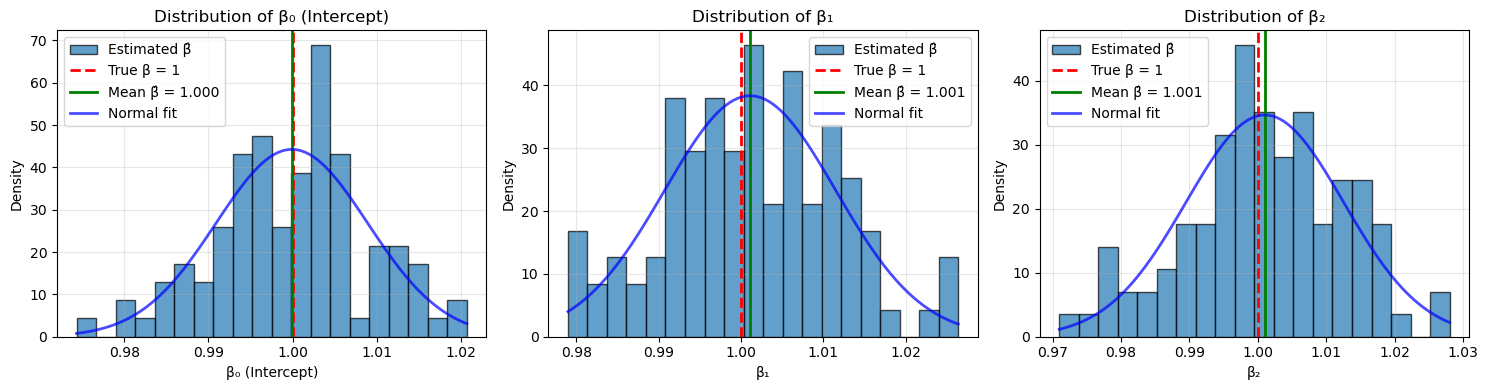

In [13]:
# Generate new data

N = 10000
S = 100
beta = [1, 1, 1]
sigma_sq = 1
rho = 0

# Y, X, beta_hats = generate_data(S, N, beta, sigma_sq, rho)

Y, X = generate_data(S, N, beta, sigma_sq, rho)

beta_hats = np.zeros((S, 3))
for s in range(S):
    beta_hats[s] = sm.OLS(Y[s], X[s]).fit().params

plot_betas(beta, beta_hats)

### Part E


Drop Value: 1.5


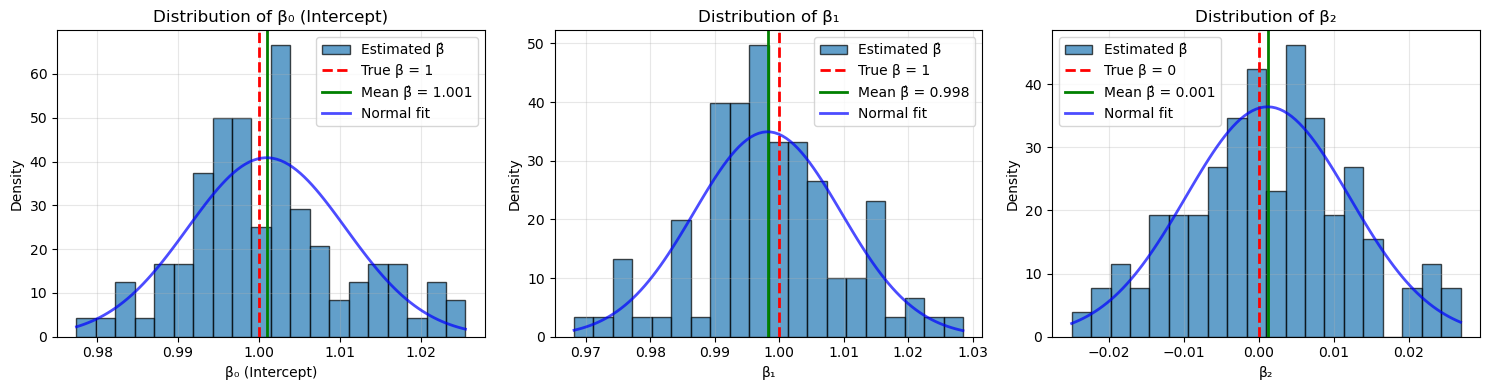

Original β̂₀ mean: 1.000894 | Filtered: 1.000927 | Mean difference in β₀: 0.000033
Original β̂₁ mean: 0.998507 | Filtered: 0.998199 | Mean difference in β₁: -0.000309
Original β̂₂ mean: 0.001056 | Filtered: 0.001157 | Mean difference in β₂: 0.000102

Average sample size after filtering: 9330.8
Percentage retained: 93.3%

Drop Value: 0.5


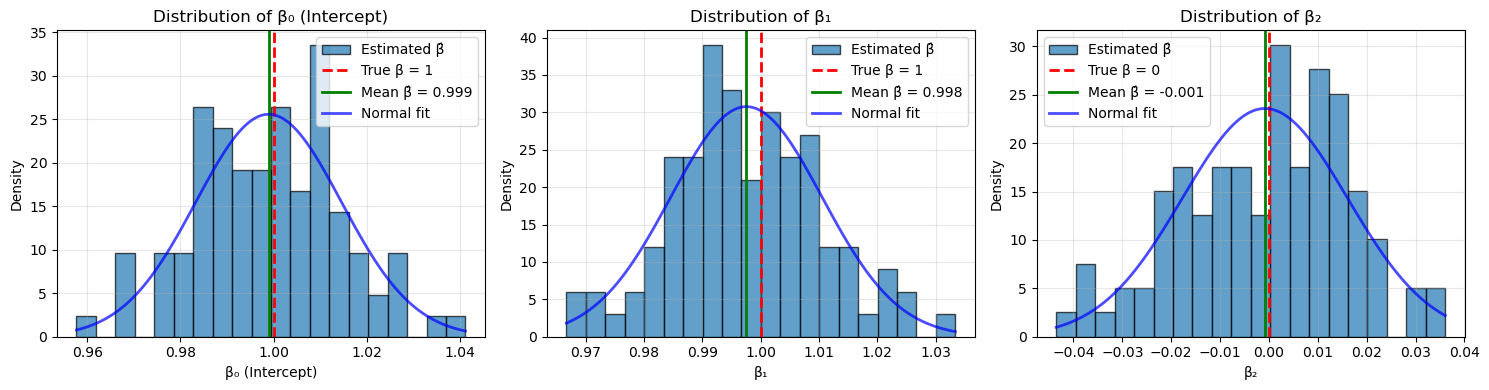

Original β̂₀ mean: 1.000894 | Filtered: 0.998940 | Mean difference in β₀: -0.001954
Original β̂₁ mean: 0.998507 | Filtered: 0.997566 | Mean difference in β₁: -0.000942
Original β̂₂ mean: 0.001056 | Filtered: -0.000821 | Mean difference in β₂: -0.001877

Average sample size after filtering: 6921.2
Percentage retained: 69.2%


In [ ]:
# Filter observations from previously generated data

for drop_value in [1.5, 0.5]:
    # Reset for each drop value
    Y_filtered_temp = []
    X_filtered_temp = []
    beta_hats_filtered = np.zeros((S, 3))
    
    for s in range(S):
        keep = X[s, :, 2] <= drop_value
        
        Y_filtered_temp.append(Y[s, keep])
        X_filtered_temp.append(X[s, keep, :])

        beta_hats_filtered[s] = sm.OLS(Y_filtered_temp[s], X_filtered_temp[s]).fit().params
    
    print(f'\n{"="*60}')
    print(f'Drop Value: {drop_value}')
    print(f'{"="*60}')
    plot_betas(beta, beta_hats_filtered)
    
    # Calculate differences from original (unfiltered) beta_hats
    diff = beta_hats_filtered - beta_hats

    print(f"Original β̂₀ mean: {beta_hats[:, 0].mean():.6f} | Filtered: {beta_hats_filtered[:, 0].mean():.6f} | Mean difference in β₀: {diff[:, 0].mean():.6f}")
    print(f"Original β̂₁ mean: {beta_hats[:, 1].mean():.6f} | Filtered: {beta_hats_filtered[:, 1].mean():.6f} | Mean difference in β₁: {diff[:, 1].mean():.6f}")
    print(f"Original β̂₂ mean: {beta_hats[:, 2].mean():.6f} | Filtered: {beta_hats_filtered[:, 2].mean():.6f} | Mean difference in β₂: {diff[:, 2].mean():.6f}")
    
    # Sample size info
    sample_sizes = [len(Y_filtered_temp[s]) for s in range(S)]
    print(f"\nAverage sample size after filtering: {np.mean(sample_sizes):.1f}")
    print(f"Percentage retained: {100 * np.mean(sample_sizes) / N:.1f}%")


The smaller drop value holds less information on the true value of the coefficient parameters, hence why more of the calculated mean values are further away from the true values.

However, an interesting observation is that despite such a large cutoff in the smaller drop value, the model is still able to calculate mean values that are surprisingly close to their true values. This motivates a hypothesis that observations where xi,3 > 0.5 might not be as important to retaining information on the data's behavior.

### Part F

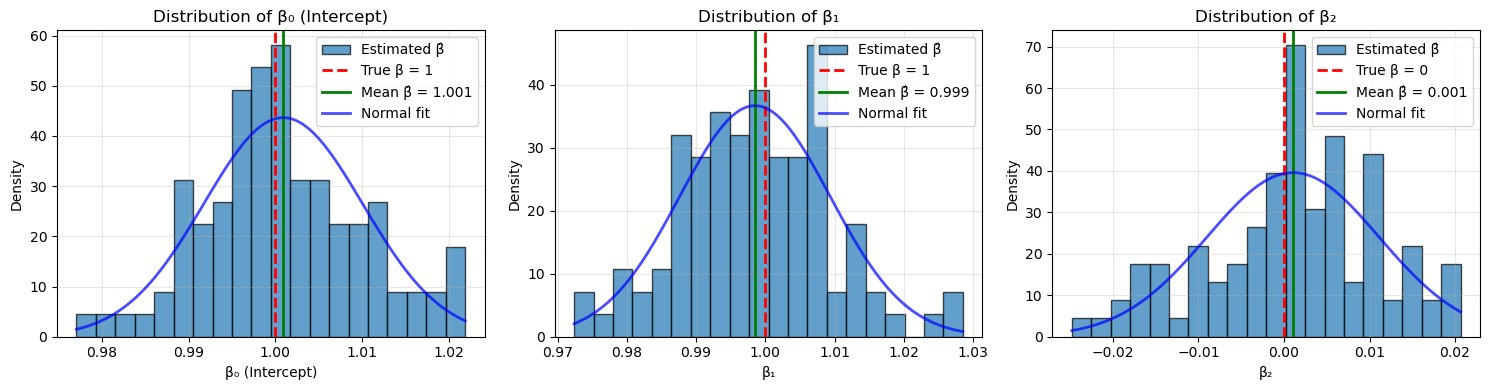

In [ ]:
# Generate new data

N = 10000
S = 100
beta = [1, 1, 0]
sigma_sq = 1
rho = 0.5

Y, X = generate_data(S, N, beta, sigma_sq, rho)

beta_hats = np.zeros((S, 3))
for s in range(S):
    beta_hats[s] = sm.OLS(Y[s], X[s]).fit().params

plot_betas(beta, beta_hats)

### Part G


Drop Value: 1.5


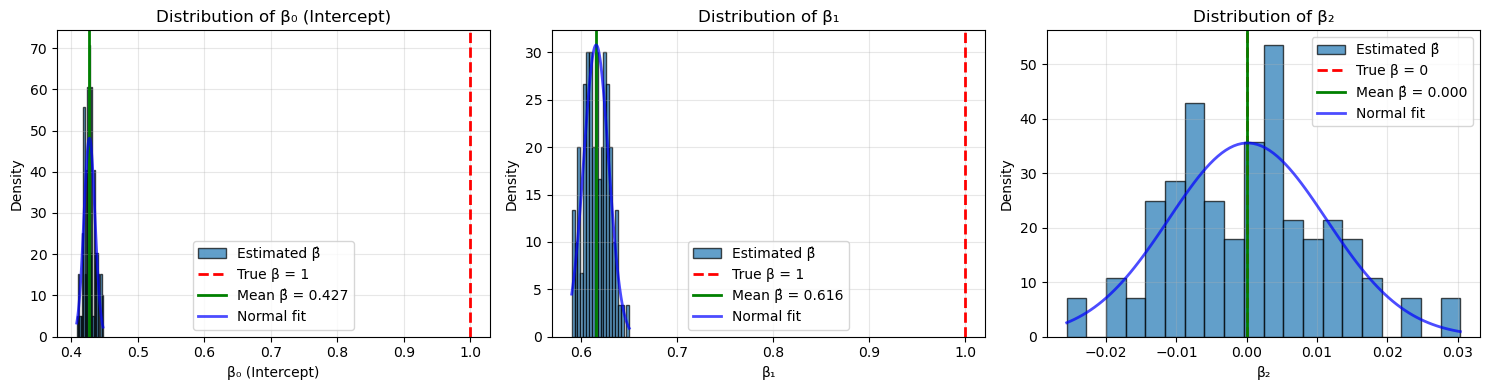

Original β̂₀ mean: 1.000894 | Filtered: 0.427158 | Mean difference in β₀: -0.573736
Original β̂₁ mean: 0.998507 | Filtered: 0.615969 | Mean difference in β₁: -0.382539
Original β̂₂ mean: 0.001056 | Filtered: 0.000106 | Mean difference in β₂: -0.000950

Average sample size after filtering: 6382.1
Percentage retained: 63.8%

Drop Value: 0.5


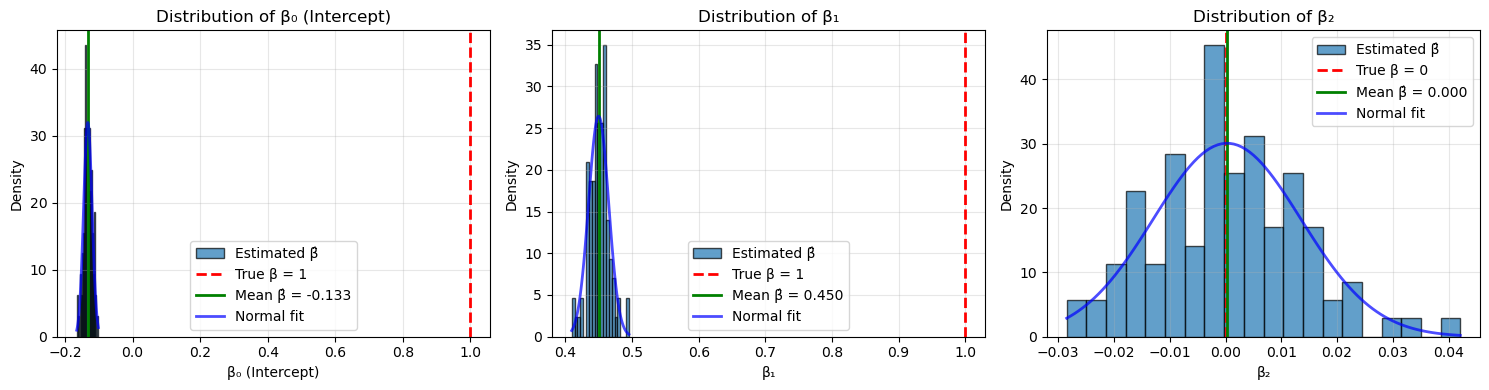

Original β̂₀ mean: 1.000894 | Filtered: -0.132793 | Mean difference in β₀: -1.133687
Original β̂₁ mean: 0.998507 | Filtered: 0.449860 | Mean difference in β₁: -0.548647
Original β̂₂ mean: 0.001056 | Filtered: 0.000279 | Mean difference in β₂: -0.000776

Average sample size after filtering: 3615.2
Percentage retained: 36.2%


In [ ]:
# Filter observations from previously generated data

for drop_value in [1.5, 0.5]:
    # Reset for each drop value
    Y_filtered_temp = []
    X_filtered_temp = []
    beta_hats_filtered = np.zeros((S, 3))
    
    for s in range(S):
        keep = Y[s] <= drop_value
        
        Y_filtered_temp.append(Y[s, keep])
        X_filtered_temp.append(X[s, keep, :])

        beta_hats_filtered[s] = sm.OLS(Y_filtered_temp[s], X_filtered_temp[s]).fit().params
    
    print(f'\n{"="*60}')
    print(f'Drop Value: {drop_value}')
    print(f'{"="*60}')
    plot_betas(beta, beta_hats_filtered)
    
    # Calculate differences from original (unfiltered) beta_hats
    diff = beta_hats_filtered - beta_hats

    print(f"Original β̂₀ mean: {beta_hats[:, 0].mean():.6f} | Filtered: {beta_hats_filtered[:, 0].mean():.6f} | Mean difference in β₀: {diff[:, 0].mean():.6f}")
    print(f"Original β̂₁ mean: {beta_hats[:, 1].mean():.6f} | Filtered: {beta_hats_filtered[:, 1].mean():.6f} | Mean difference in β₁: {diff[:, 1].mean():.6f}")
    print(f"Original β̂₂ mean: {beta_hats[:, 2].mean():.6f} | Filtered: {beta_hats_filtered[:, 2].mean():.6f} | Mean difference in β₂: {diff[:, 2].mean():.6f}")
    
    # Sample size info
    sample_sizes = [len(Y_filtered_temp[s]) for s in range(S)]
    print(f"\nAverage sample size after filtering: {np.mean(sample_sizes):.1f}")
    print(f"Percentage retained: {100 * np.mean(sample_sizes) / N:.1f}%")


For these outputs, there is a strong negative bias due to strong selection bias for beta_0 and beta_1.